<a href="https://colab.research.google.com/github/poojithavakada7-hue/Diabetic_Prediction/blob/main/Diabetic_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix




In [ ]:
df = pd.read_csv("ppg_diabetes_synthetic_dataset.csv")

print("First 5 rows of dataset:")
print(df.head())

print("\nDataset Information:")
print(df.info())

First 5 rows of dataset:
   Age  HeartRate   Temp  PulseAmplitude  RiseTime  PulseWidth  HRV  IRSignal  \
0   56         77  36.62           0.870     0.133       0.359   67     0.892   
1   69         86  36.78           0.830     0.210       0.461   23     0.941   
2   46         64  36.08           0.614     0.272       0.287   44     0.785   
3   32         64  36.62           0.712     0.203       0.442   71     0.835   
4   60         90  36.62           0.923     0.237       0.234   69     0.704   

   Label  
0      1  
1      0  
2      1  
3      0  
4      1  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             5000 non-null   int64  
 1   HeartRate       5000 non-null   int64  
 2   Temp            5000 non-null   float64
 3   PulseAmplitude  5000 non-null   float64
 4   RiseTime        500

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing values if any
df = df.fillna(df.mean())


Missing Values:
Age               0
HeartRate         0
Temp              0
PulseAmplitude    0
RiseTime          0
PulseWidth        0
HRV               0
IRSignal          0
Label             0
dtype: int64


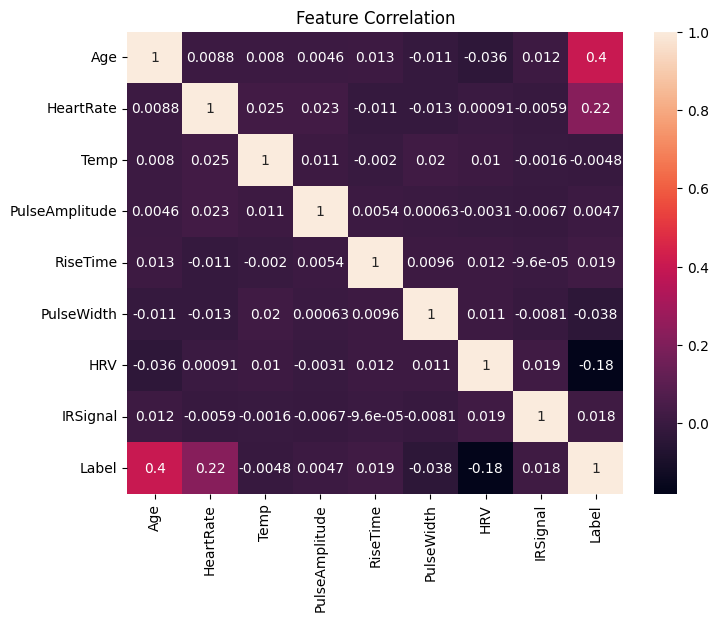

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()


In [ ]:
X = df[['Age','HeartRate','Temp','PulseAmplitude',
        'RiseTime','PulseWidth','HRV','IRSignal']]

y = df['Label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("\nModel Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Model Accuracy: 0.898

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.73      0.79       263
           1       0.91      0.96      0.93       737

    accuracy                           0.90      1000
   macro avg       0.88      0.84      0.86      1000
weighted avg       0.90      0.90      0.90      1000



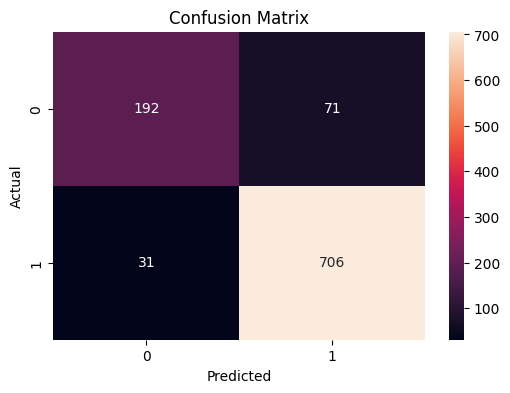

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

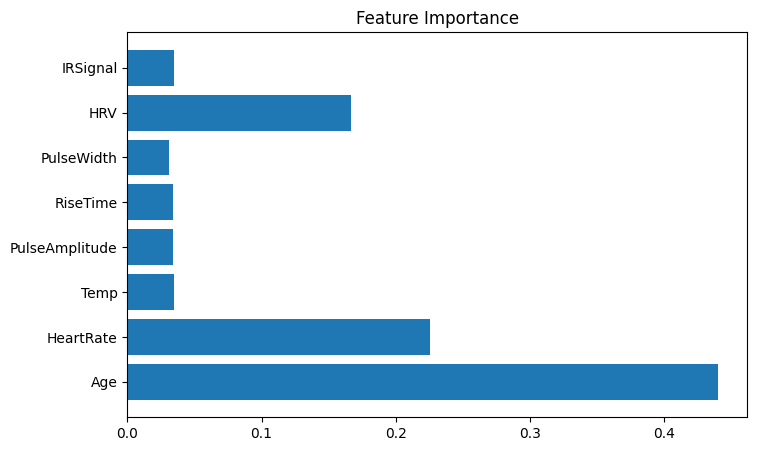

In [ ]:
importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()


In [ ]:
sample = [[50, 90, 37.3, 0.65, 0.22, 0.45, 30, 0.75]]

sample = scaler.transform(sample)

prediction = model.predict(sample)

print("\nPrediction Result:", prediction)

if prediction[0] == 0:
    print("Person is Normal")
else:
    print("Person may have Diabetes")

In [ ]:
age = float(input("Enter Age: "))
hr = float(input("Enter Heart Rate: "))
temp = float(input("Enter Temperature: "))
pa = float(input("Enter Pulse Amplitude: "))
rt = float(input("Enter Rise Time: "))
pw = float(input("Enter Pulse Width: "))
hrv = float(input("Enter HRV: "))
ir = float(input("Enter IR Signal: "))

data = [[age, hr, temp, pa, rt, pw, hrv, ir]]

data_scaled = scaler.transform(data)

prediction = model.predict(data_scaled)

if prediction[0] == 0:
    print("Result: Normal")
else:
    print("Result: Diabetic")

Enter Age: 50
Enter Heart Rate: 90
Enter Temperature: 37.3
Enter Pulse Amplitude: 0.65
Enter Rise Time: 0.22
Enter Pulse Width: 0.45
Enter HRV: 30
Enter IR Signal: 0.75
Result: Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Multiple persons data
persons = [
    [30,72,36.6,0.82,0.14,0.29,48,0.91],
    [55,95,37.5,0.60,0.23,0.45,28,0.72],
    [45,88,37.1,0.65,0.20,0.40,35,0.80]
]

persons_scaled = scaler.transform(persons)

predictions = model.predict(persons_scaled)

for i, p in enumerate(predictions):
    if p == 0:
        print("Person", i+1, ": Normal")
    else:
        print("Person", i+1, ": Diabetic")

Person 1 : Normal
Person 2 : Diabetic
Person 3 : Normal


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
